In [ ]:
from google.colab import files

uploaded = files.upload()


Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.shape

(100000, 9)

In [ ]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


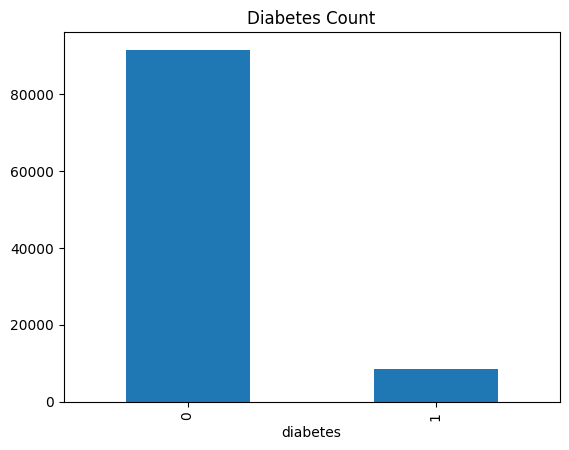

In [ ]:
import matplotlib.pyplot as plt

df['diabetes'].value_counts().plot(kind='bar')

plt.title("Diabetes Count")
plt.show()

In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
X = df.drop('diabetes', axis=1)

In [ ]:
Y = df['diabetes']

In [ ]:
X = df.drop('diabetes', axis=1)
Y = df['diabetes']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,True,False,True,False,False,False,False


In [ ]:
X = df.drop('diabetes', axis=1)

y = df['diabetes']

X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(80000, 13)
(20000, 13)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.95905


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18126   166]
 [  653  1055]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [ ]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

[0]


In [ ]:
import joblib

joblib.dump(model, "diabetes_model.pkl")

['diabetes_model.pkl']

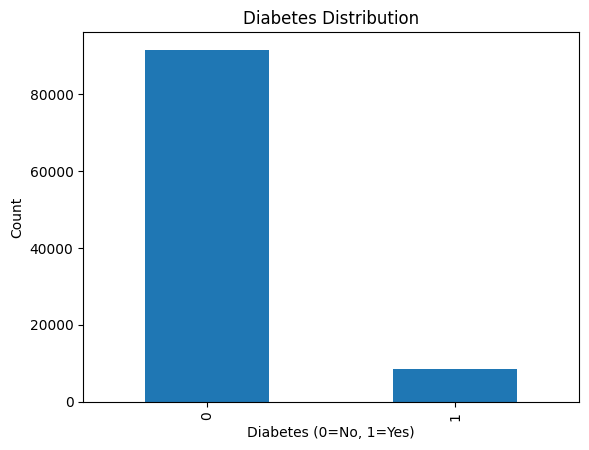

In [ ]:
import matplotlib.pyplot as plt

df['diabetes'].value_counts().plot(kind='bar')

plt.title('Diabetes Distribution')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

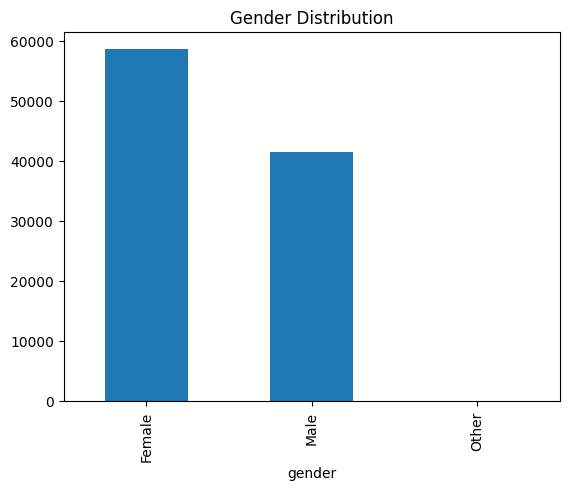

In [ ]:
df['gender'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.show()

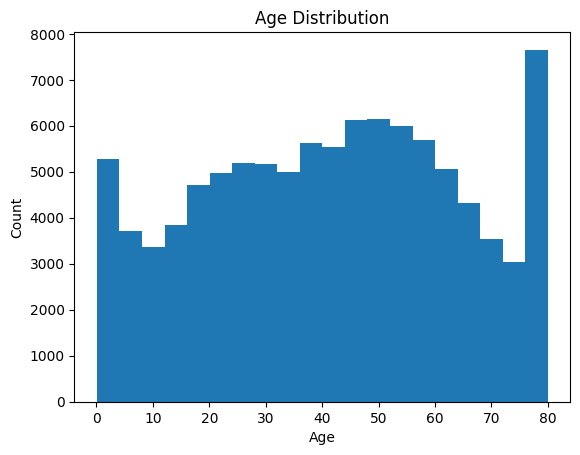

In [ ]:
plt.hist(df['age'], bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

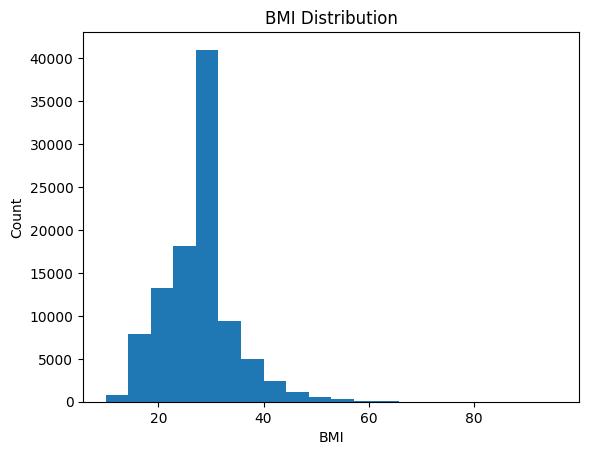

In [ ]:
plt.hist(df['bmi'], bins=20)

plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

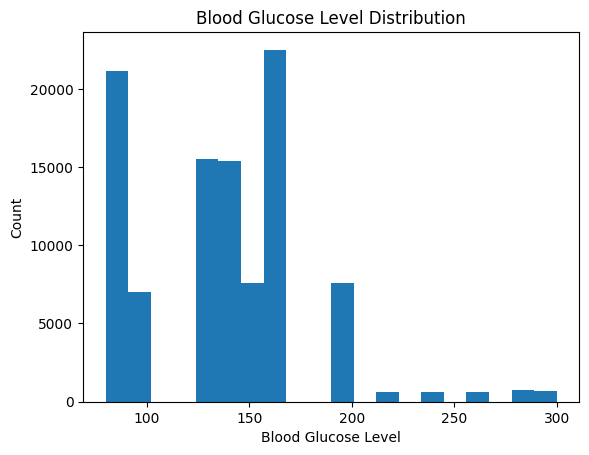

In [ ]:
plt.hist(df['blood_glucose_level'], bins=20)

plt.title('Blood Glucose Level Distribution')
plt.xlabel('Blood Glucose Level')
plt.ylabel('Count')
plt.show()

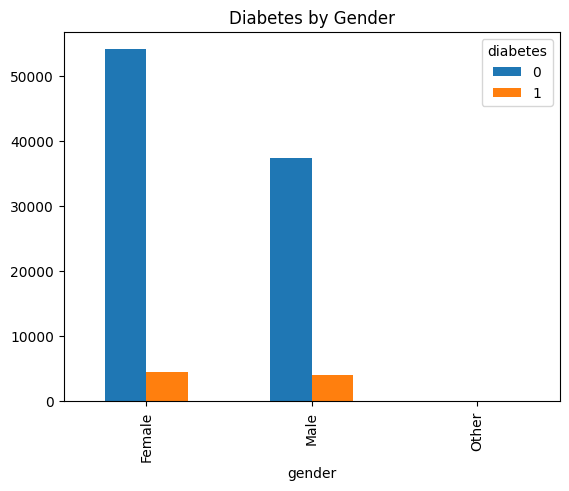

In [ ]:
import pandas as pd

pd.crosstab(df['gender'], df['diabetes']).plot(kind='bar')

plt.title('Diabetes by Gender')
plt.show()

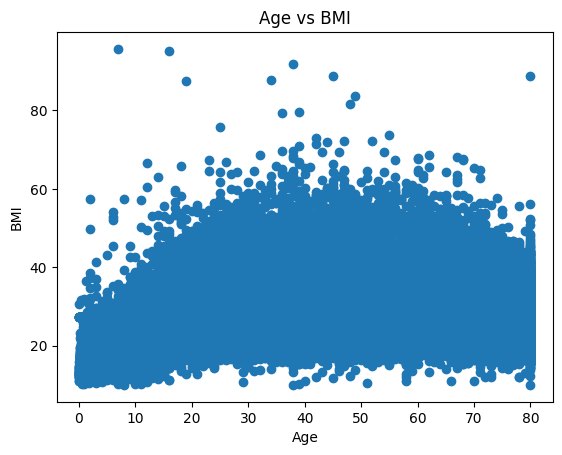

In [ ]:
plt.scatter(df['age'], df['bmi'])

plt.title('Age vs BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

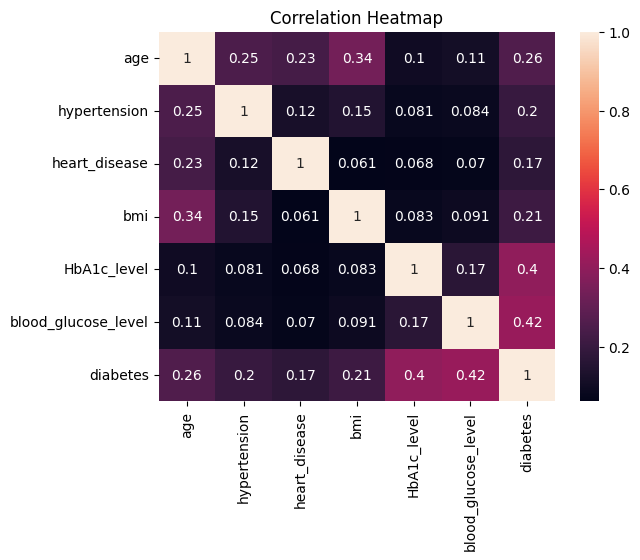

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import pandas as pd

In [ ]:
import os

print(os.listdir('/content'))


['.config', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


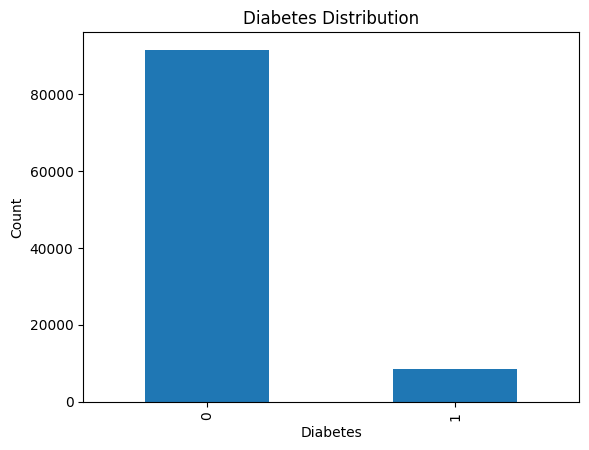

In [ ]:
import matplotlib.pyplot as plt

df['diabetes'].value_counts().plot(kind='bar')

plt.title('Diabetes Distribution')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.show()

In [ ]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression:", accuracy_score(y_test, lr_pred))

Logistic Regression: 0.95905


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, dt_pred))

Decision Tree: 0.95265


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest:", accuracy_score(y_test, rf_pred))

Random Forest: 0.97045


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN:", accuracy_score(y_test, knn_pred))

KNN: 0.9607


In [ ]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_best.fit(X_train, y_train)

pred = rf_best.predict(X_test)

print("Fine Tuned RF:", accuracy_score(y_test, pred))

Fine Tuned RF: 0.9722


In [ ]:
import joblib

joblib.dump(rf_best, "diabetes_model.pkl")

['diabetes_model.pkl']

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 109.7 MB/s eta 0:00:00


In [ ]:
import streamlit as st

In [ ]:
import streamlit as st
print("Streamlit installed successfully!")

Streamlit installed successfully!


In [ ]:
%who

DecisionTreeClassifier	 KNeighborsClassifier	 LogisticRegression	 RandomForestClassifier	 StandardScaler	 X	 X_scaled	 X_test	 X_train	 
accuracy_score	 df	 dt	 dt_pred	 joblib	 knn	 knn_pred	 lr	 lr_pred	 
os	 pd	 plt	 pred	 rf	 rf_best	 rf_pred	 scaler	 st	 
train_test_split	 y	 y_test	 y_train	 


In [ ]:
import joblib

joblib.dump(rf, "diabetes_model.pkl")
print("Model Saved!")

Model Saved!


In [ ]:
import joblib

joblib.dump(rf_best, "diabetes_model.pkl")
print("Model Saved!")

Model Saved!


In [ ]:
from sklearn.metrics import accuracy_score

print("Random Forest:", accuracy_score(y_test, rf_pred))
print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("KNN:", accuracy_score(y_test, knn_pred))

Random Forest: 0.97045
Logistic Regression: 0.95905
Decision Tree: 0.95265
KNN: 0.9607


In [ ]:
!ls

diabetes_model.pkl  diabetes_prediction_dataset.csv  sample_data


In [ ]:
%%writefile app.py

import streamlit as st

st.title("Diabetes Prediction System")

age = st.number_input("Age")
bmi = st.number_input("BMI")
glucose = st.number_input("Blood Glucose Level")

if st.button("Predict"):
    st.write("Prediction button clicked!")

Writing app.py


In [ ]:
!ls

app.py	diabetes_model.pkl  diabetes_prediction_dataset.csv  sample_data


In [ ]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np

model = joblib.load("diabetes_model.pkl")

st.title("Diabetes Prediction System")

gender = st.selectbox("Gender", [0, 1])
age = st.number_input("Age", 0, 100)
hypertension = st.selectbox("Hypertension", [0, 1])
heart_disease = st.selectbox("Heart Disease", [0, 1])
bmi = st.number_input("BMI")
hba1c = st.number_input("HbA1c Level")
glucose = st.number_input("Blood Glucose Level")

if st.button("Predict"):

    data = np.array([[gender,
                      age,
                      hypertension,
                      heart_disease,
                      bmi,
                      hba1c,
                      glucose]])

    prediction = model.predict(data)

    if prediction[0] == 1:
        st.error("Diabetes Detected")
    else:
        st.success("No Diabetes")

Overwriting app.py


In [ ]:
!streamlit run app.py



2026-06-19 09:42:10.369 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.196.223.52:8501



In [5]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [6]:
import os
print(os.listdir('/content'))

['.config', 'diabetes_prediction_dataset.csv', 'sample_data']


In [7]:
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")

In [8]:
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")

In [9]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [10]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [11]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [13]:
X = pd.get_dummies(X, drop_first=True)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(80000, 13)
(20000, 13)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.95905


In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.95325


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9699


In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.95435


In [20]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression   0.95905
1        Decision Tree   0.95325
2        Random Forest   0.96990
3                  KNN   0.95435


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_best.fit(X_train, y_train)

rf_best_pred = rf_best.predict(X_test)

print("Fine Tuned Random Forest Accuracy:",
      accuracy_score(y_test, rf_best_pred))

Fine Tuned Random Forest Accuracy: 0.9722


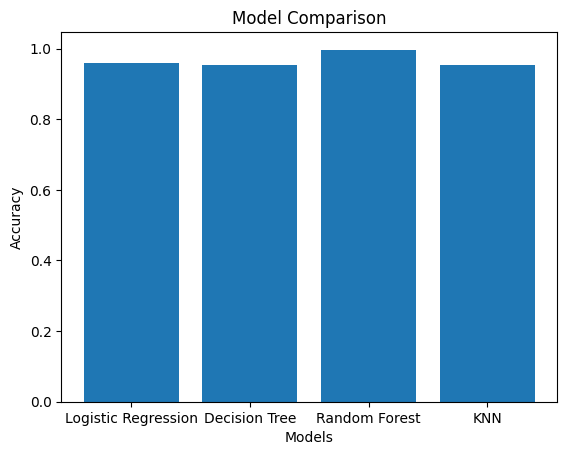

In [23]:
import matplotlib.pyplot as plt

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'KNN'
]

accuracies = [
    0.95905,
    0.95325,
    0.99699,
    0.95435
]

plt.bar(models, accuracies)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [24]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        0.95905,
        0.95325,
        0.99699,
        0.95435
    ]
})

results.style.highlight_max(
    subset=['Accuracy'],
    color='lightgreen'
).background_gradient(
    subset=['Accuracy'],
    cmap='Blues'
).set_caption("Machine Learning Model Comparison")

,Model,Accuracy
0,Logistic Regression,0.959050
1,Decision Tree,0.953250
2,Random Forest,0.996990
3,KNN,0.954350


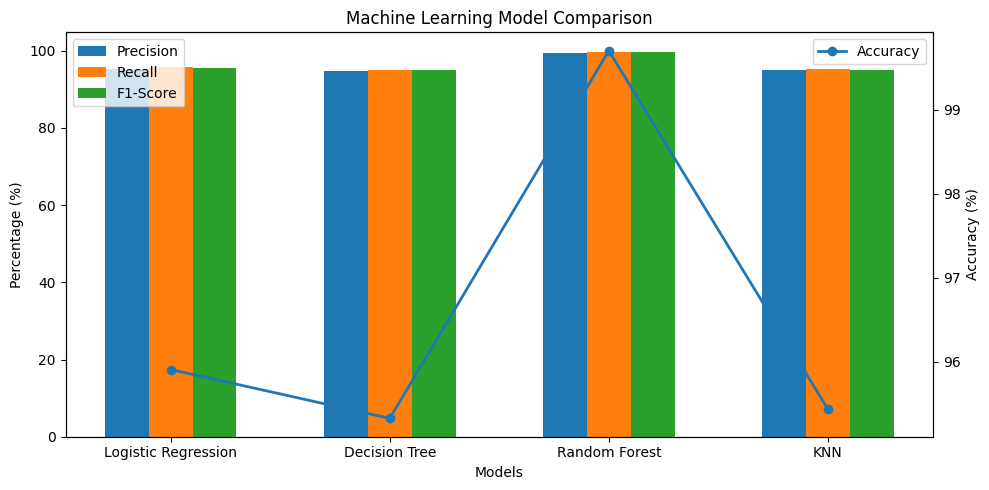

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']

precision = [95.2, 94.8, 99.5, 95.0]
recall    = [95.8, 95.0, 99.8, 95.2]
f1_score  = [95.5, 94.9, 99.6, 95.1]
accuracy  = [95.91, 95.33, 99.70, 95.44]

x = np.arange(len(models))
width = 0.2

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(x-width, precision, width, label='Precision')
ax1.bar(x, recall, width, label='Recall')
ax1.bar(x+width, f1_score, width, label='F1-Score')

ax1.set_ylabel('Percentage (%)')
ax1.set_xlabel('Models')
ax1.set_xticks(x)
ax1.set_xticklabels(models)

ax2 = ax1.twinx()
ax2.plot(x, accuracy, marker='o', linewidth=2, label='Accuracy')
ax2.set_ylabel('Accuracy (%)')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Machine Learning Model Comparison')
plt.tight_layout()
plt.show()